# Predictive Maintenance - Data Exploration (Stage 1)

In this notebook, we load the `train_FD001.txt` dataset and explore the raw sensor readings to understand overall trends and operating modes.

We also calculate the RUL (Remaining Useful Life) which will serve as our target variable for modelling.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context('notebook')
sns.set_style('whitegrid')

## 1. Data Loading
The dataset `train_FD001.txt` consists of multiple time series representing different engines. The first two columns represent the engine ID and cycle number. The next 3 columns are operational settings, and the remaining 21 columns are sensor measurements.

In [10]:
# Define column names for CMAPSS data
columns = ['unit_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3'] + \
          [f'sensor_{i}' for i in range(1, 22)]

# Load the dataset
df_train = pd.read_csv('../data/raw/train_FD001.txt', sep='\\s+', names=columns)

print(f"Shape of training data: {df_train.shape}")
df_train.head()

Shape of training data: (20631, 26)


,unit_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## 2. Basic Exploration
Let's check the basic statistics and see if there are any missing values.

In [11]:
# Summary statistics
display(df_train.describe())

# Check for missing values
print("\nMissing Values:\n", df_train.isnull().sum().sum())

,unit_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,5.329200e-15,...,0.737553,0.071919,19.076176,0.037505,3.469531e-18,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400



Missing Values:
 0


## 3. RUL Calculation (Remaining Useful Life)
In the training data, each run ends with an engine failure. Therefore, the RUL for any given cycle is the difference between the total cycles of that engine and its current cycle.

In [12]:
# Calculate RUL
def calculate_rul(df):
    # Get maximum cycle length for each engine
    max_cycles = df.groupby('unit_id')['cycle'].max()
    # Merge back to original dataframe
    result_frame = df.merge(max_cycles.to_frame(name='max_cycle'), left_on='unit_id', right_index=True)
    # Calculate RUL
    result_frame['RUL'] = result_frame['max_cycle'] - result_frame['cycle']
    result_frame.drop('max_cycle', axis=1, inplace=True)
    return result_frame

df_train = calculate_rul(df_train)

df_train.head()

,unit_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


## 4. Visualizations
Let's visualize the relationship between sensor readings and the newly calculated RUL for a specific engine.

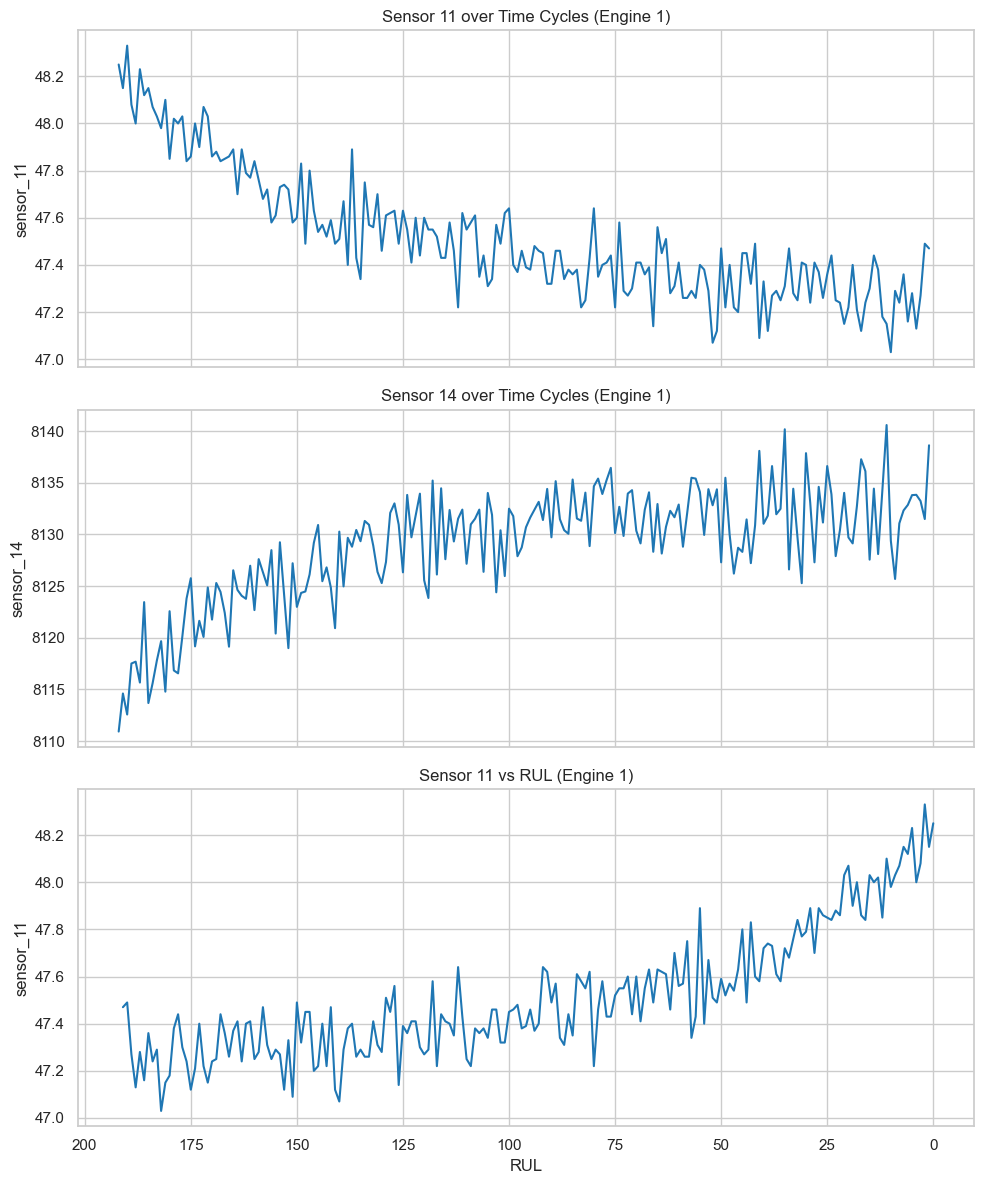

In [13]:
df_engine_1 = df_train[df_train['unit_id'] == 1]

fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

sns.lineplot(data=df_engine_1, x='cycle', y='sensor_11', ax=axes[0])
axes[0].set_title('Sensor 11 over Time Cycles (Engine 1)')

sns.lineplot(data=df_engine_1, x='cycle', y='sensor_14', ax=axes[1])
axes[1].set_title('Sensor 14 over Time Cycles (Engine 1)')

sns.lineplot(data=df_engine_1, x='RUL', y='sensor_11', ax=axes[2])
axes[2].set_title('Sensor 11 vs RUL (Engine 1)')
axes[2].invert_xaxis()  # RUL counts down

plt.tight_layout()
plt.show()

## 5. Correlation Analysis
Let's see which sensors are most strongly correlated with RUL to determine feature importance.

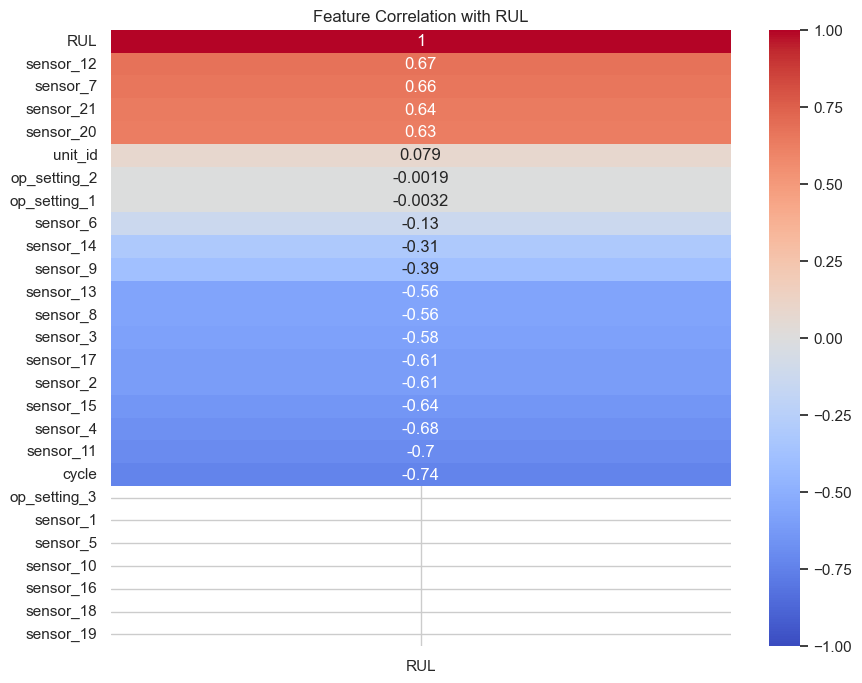

In [14]:
plt.figure(figsize=(10, 8))
# Calculate correlation with RUL and sort
corr = df_train.corr()
rul_corr = corr[['RUL']].sort_values(by='RUL', ascending=False)
sns.heatmap(rul_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation with RUL')
plt.show()

## 6. Constant Sensors
Some sensors (like sensor_1, sensor_5, sensor_10, sensor_16, sensor_18, sensor_19) show zero variance throughout the engine's lifecycle. Let's visualize this for a single engine to justify dropping them during preprocessing.

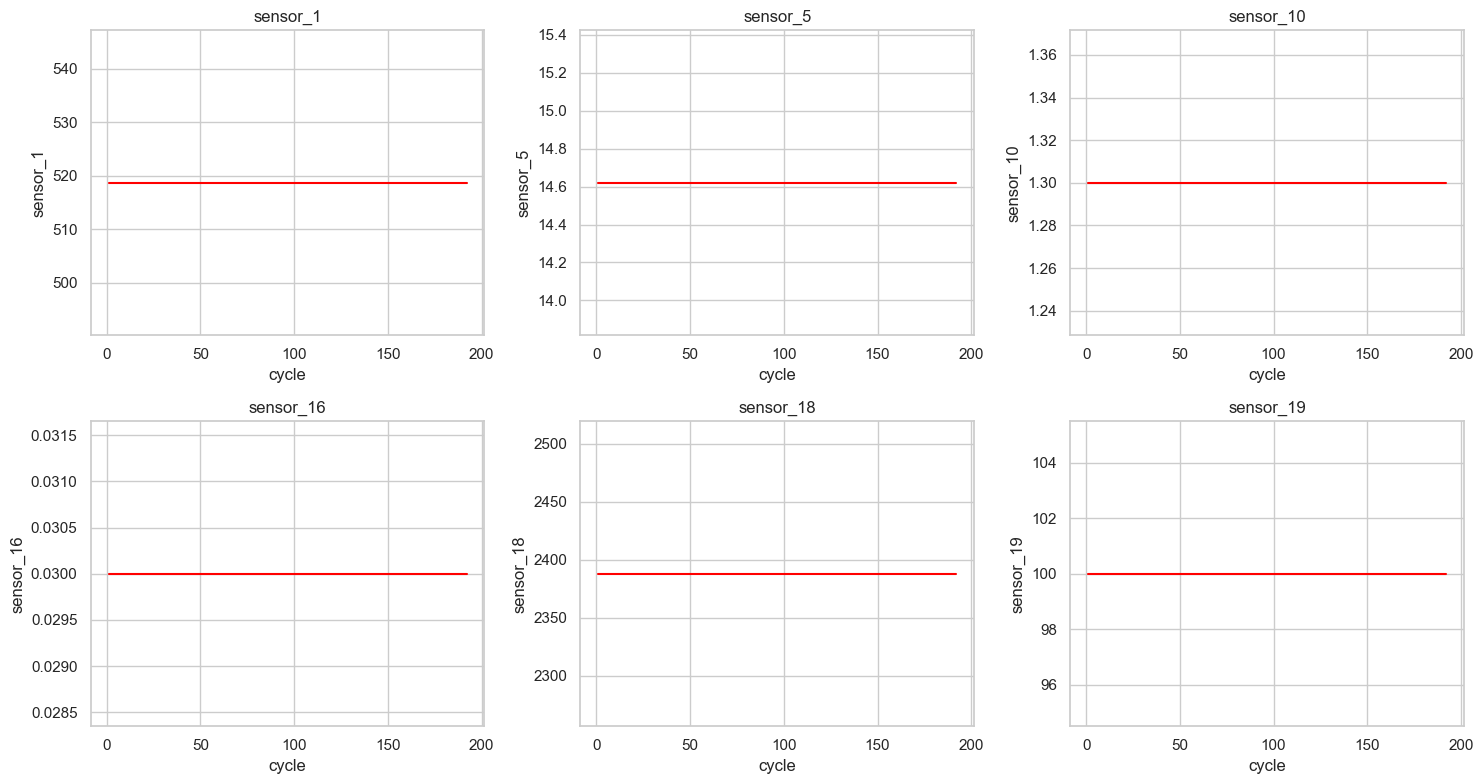

In [15]:
constant_sensors = ['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

engine_1 = df_train[df_train['unit_id'] == 1]

for i, sensor in enumerate(constant_sensors):
    sns.lineplot(data=engine_1, x='cycle', y=sensor, ax=axes[i], color='red')
    axes[i].set_title(sensor)

plt.tight_layout()
plt.show()

## 7. Degrading Sensors (Non-Constant)
Now let's look at the sensors that actually matter. These are the sensors that showed high correlation with RUL in our heatmap above. We expect to see clear upward or downward trends as the engine approaches failure.

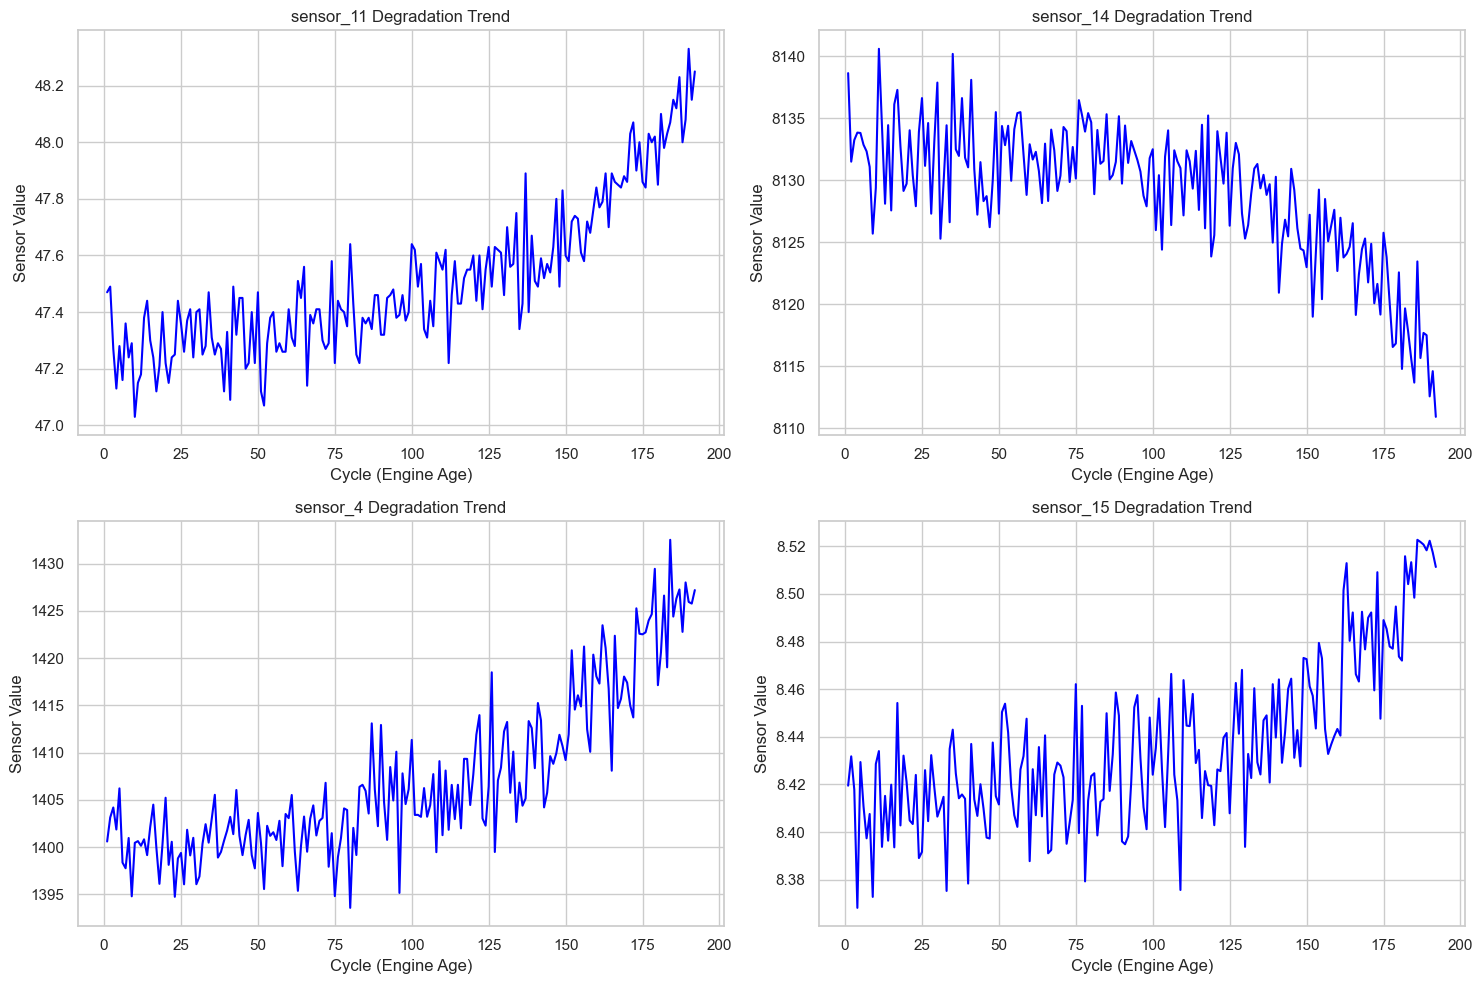

In [16]:
# Selecting top 4 sensors with highest absolute correlation to RUL
top_sensors = ['sensor_11', 'sensor_14', 'sensor_4', 'sensor_15']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

engine_1 = df_train[df_train['unit_id'] == 1]

for i, sensor in enumerate(top_sensors):
    sns.lineplot(data=engine_1, x='cycle', y=sensor, ax=axes[i], color='blue')
    axes[i].set_title(f'{sensor} Degradation Trend')
    axes[i].set_ylabel('Sensor Value')
    axes[i].set_xlabel('Cycle (Engine Age)')

plt.tight_layout()
plt.show()